In [1]:
# Cargamos librerías básicas de análisis y modelado
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_recall_curve, auc as pr_auc

import xgboost as xgb
import shap

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

/Users/anynou/Documents/mis_repos/data-projects/data-projects_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Cargar datos

In [2]:
data_path = "streaming_data.csv"

df = pd.read_csv(data_path)

print("Forma del dataset:", df.shape)
print("\nLas primeras filas:")
display(df.head())

print("\nTipos de datos:")
print(df.dtypes)

Forma del dataset: (50000, 18)

Las primeras filas:


,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,1,France,25,2021-08-19,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,2,Indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,3,Italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,4,Italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,5,Australia,18,2020-05-29,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11



Tipos de datos:
user_id                             int64
country                               str
age                                 int64
signup_date                           str
subscription_type                     str
subscription_status                   str
months_inactive                     int64
inactive_3_months_flag              int64
ad_interaction                        str
ad_conversion_to_subscription         str
music_suggestion_rating_1_to_5      int64
avg_listening_hours_per_week      float64
favorite_genre                        str
most_liked_feature                    str
desired_future_feature                str
primary_device                        str
playlists_created                   int64
avg_skips_per_day                   int64
dtype: object


## Limpieza y feature engineering

In [3]:
df = df.dropna()

df["signup_date"] = pd.to_datetime(df["signup_date"])
df["days_since_signup"] = (df["signup_date"].max() - df["signup_date"]).dt.days

# Señales de bajo engagement
df["low_engagement"] = df["avg_listening_hours_per_week"] < 3
df["short_time"] = df["days_since_signup"] < 90

# churn = 1 si ha estado 2 meses inactivo y tiene baja escucha o es nuevo
df["churn"] = 0
df.loc[
    (df["months_inactive"] >= 2) & (df["low_engagement"] | df["short_time"]),
    "churn"
] = 1
    
target_col = "churn"

# Selección de columnas
feature_cols = [
    "age",
    "country",
    "primary_device",
    "favorite_genre",
    "most_liked_feature",
    "desired_future_feature",
    "subscription_type",
    "days_since_signup",
    "avg_listening_hours_per_week",
    "playlists_created",
    "avg_skips_per_day",
    "music_suggestion_rating_1_to_5",
    "ad_interaction",
    "ad_conversion_to_subscription",
]

df = df.drop(["user_id", "subscription_status", "signup_date"], axis=1)

X = df[feature_cols].copy()
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 14)
y shape: (50000,)


## Preparar categorías

In [4]:
# Identificar variables categóricas
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
print("Categóricas:", cat_cols)

# Label Encoding para todas las categóricas
from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))


Categóricas: ['country', 'primary_device', 'favorite_genre', 'most_liked_feature', 'desired_future_feature', 'subscription_type', 'ad_interaction', 'ad_conversion_to_subscription']


/var/folders/s5/sx2yvvwn6_q1zlbl7z0m0qqc0000gp/T/ipykernel_8015/2210809814.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


## Train / Test

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y      
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("y_train.value_counts(normalize=True):\n", y_train.value_counts(normalize=True))

X_train: (40000, 14)
y_train: (40000,)
y_train.value_counts(normalize=True):
 churn
0    0.97395
1    0.02605
Name: proportion, dtype: float64


## Modelo

In [6]:
model = xgb.XGBClassifier(
    objective="binary:logistic",
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]),  # ajusta peso de churn
    random_state=42,
    eval_metric="auc"
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## Evaluación

In [8]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

auc = roc_auc_score(y_test, y_pred_proba)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc_score = pr_auc(recall, precision)

print("AUC:", round(auc, 3))
print("Precision-Recall AUC:", round(pr_auc_score, 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

AUC: 0.976
Precision-Recall AUC: 0.365

Classification Report:
              precision    recall  f1-score   support

    No Churn       1.00      0.96      0.98      9740
       Churn       0.37      0.86      0.52       260

    accuracy                           0.96     10000
   macro avg       0.69      0.91      0.75     10000
weighted avg       0.98      0.96      0.97     10000



## Matriz de confusión

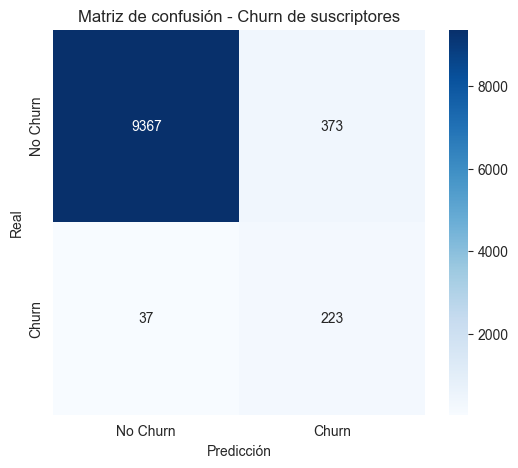

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title("Matriz de confusión - Churn de suscriptores")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

## Importancia de variables

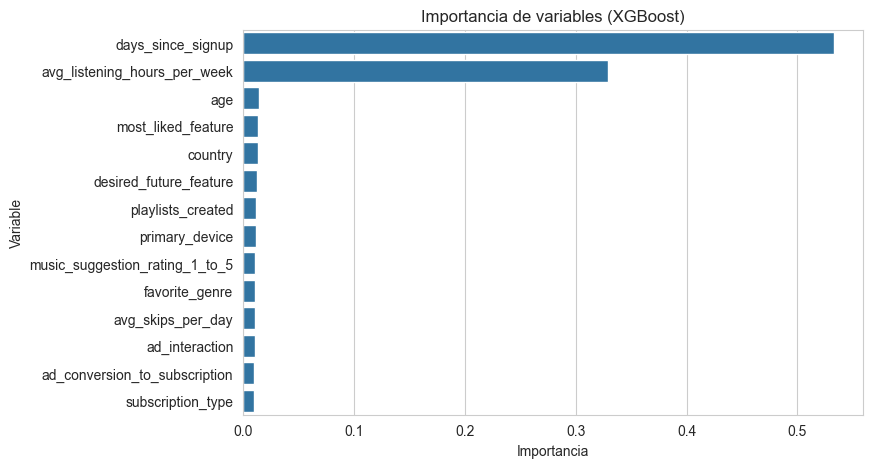

In [10]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Importancia de variables (XGBoost)")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

## Impacto de variables en el modelo

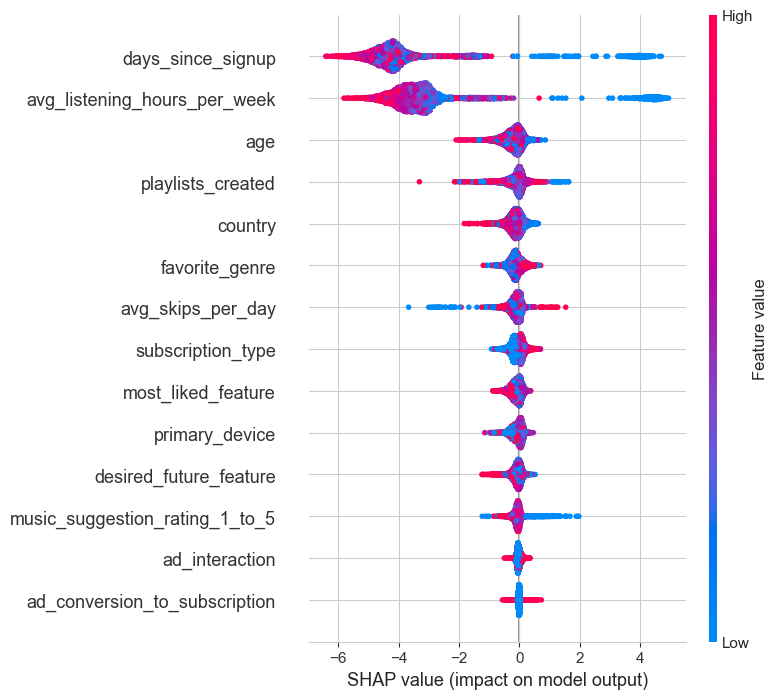

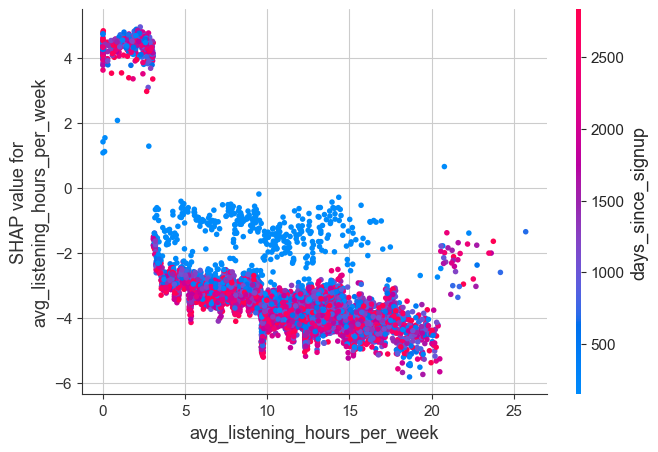

In [11]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, show=True)
shap.dependence_plot("avg_listening_hours_per_week", shap_values, X_test)

## Ejemplo predicción

Probabilidad de churn para este usuario: 0.0
Predicción: 0


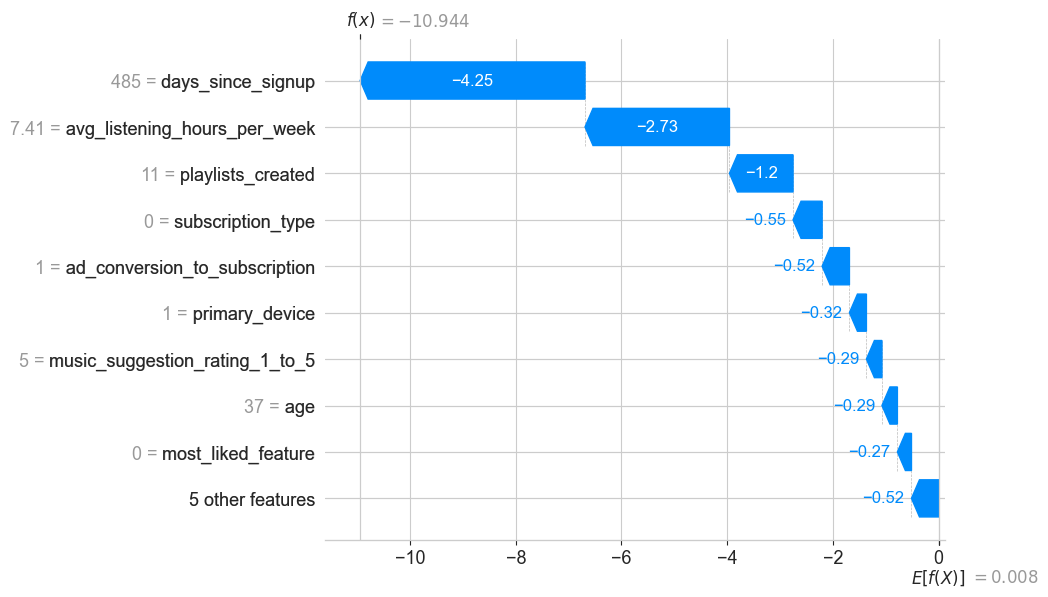

In [12]:

new_user = X_test.iloc[:1].copy()

prob = model.predict_proba(new_user)[:, 1][0]
pred = model.predict(new_user)[0]

print("Probabilidad de churn para este usuario:", prob.round(3))
print("Predicción:", pred)

shap_values_single = explainer.shap_values(new_user)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_single[0],
        base_values=explainer.expected_value,
        data=new_user.iloc[0],
        feature_names=new_user.columns.tolist()
    )
)